In [58]:
import senpi
from senpi import *
from senpi.sim.simulator import EventSimulator
from senpi.sim.params import make_params
import torch
import numpy as np
import matplotlib.pyplot as plt

In [59]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# First, generate user params and check if accurate
params = make_params()
print(params)

# Next, create instance of event simulator class and check some initialized quantities
es = EventSimulator(params=params)
print(es.params)  # should match above
print(es.hot_map)  # empty upon initialization
print(es.noise_map)
print(es.pos_map)

# Now, test initialization of internal grids of event camera and recheck initialized quantities
es._generate_internal_properties(im_size = [100, 100])
print(es.hot_map)  # empty upon initialization
print(es.noise_map)
print(es.pos_map)

{'refractory': 50, 'well_cap': 15000, 'QE': 1, 'dt': 50, 'pos_th': 0.1, 'neg_th': -0.1, 'sigma_pos': 0.0, 'sigma_neg': 0.0, 'leak_rate': 0.05, 'sigma_leak': 0.01, 'return_frame': 1, 'return_events': 0, 'shot_noise': 0, 'sensor_noise': 1, 'hot_prob': 0, 'hot_rate': 0.9, 'dark_e': 2.0, 'seed': 1, 'v1': 0.05, 'sigma_v1': 0.01, 'device': device(type='cuda')}
{'refractory': 50, 'well_cap': 15000, 'QE': 1, 'dt': 50, 'pos_th': 0.1, 'neg_th': -0.1, 'sigma_pos': 0.0, 'sigma_neg': 0.0, 'leak_rate': 0.05, 'sigma_leak': 0.01, 'return_frame': 1, 'return_events': 0, 'shot_noise': 0, 'sensor_noise': 1, 'hot_prob': 0, 'hot_rate': 0.9, 'dark_e': 2.0, 'seed': 1, 'v1': 0.05, 'sigma_v1': 0.01, 'device': device(type='cuda')}
[]
[]
[]
tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0')
tensor([[0.0442, 0.0398, 0.0583,  ..., 0.0

In [61]:
from tqdm import tqdm
from notebook_video_writer import VideoWriter

# Lets generate a dummy object to test the forward model - a spatiotemporal sinusoid
vid_size = [250, 50, 200]  # declared in [t, x, y]
v1 = torch.ones(size=vid_size[1:]) * 0.02  # explicitly declare a low uniform starting reference voltage (else defined in params)
stack = torch.zeros(size=vid_size, dtype=torch.float)  # preallocate
peak_photons = params["well_cap"]  # peak of signal is well cap of sensor
fx = 1/50  # spatial frequency in units of 1/pixels
ft = 1/200  # temporal frequency in units of 1/dt

# set up appropriate grids for video object
xx = torch.arange(0, vid_size[2], dtype=torch.float32)
xx = xx.repeat(vid_size[1], 1)

# write a video to the notebook to visualize result!
with VideoWriter(filename="es_intensity.mp4", fps=30) as vw:
    for i in tqdm(range(vid_size[0])):

        # # for visualization
        frame = (torch.sin(2*np.pi*fx*xx + 2*np.pi*i*ft*params["dt"]).numpy() + 1) * 1/2
        vw.add(frame)

        # for assignment
        stack[i, :] = torch.ceil(0.75*peak_photons * torch.from_numpy(frame))+1  # round to whole numbers up so always have a photon

100%|██████████| 250/250 [00:00<00:00, 1543.47it/s]


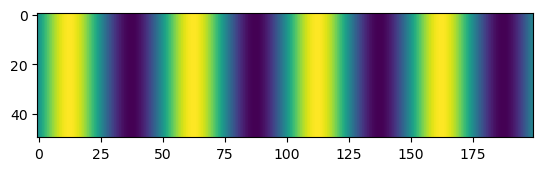

In [62]:
# Show a fixed photon frame for comparison
plt.figure()
plt.imshow(torch.squeeze(stack[200,:]).detach().cpu().numpy())

tensor(0.8980) tensor(-0.6376)
tensor(1.)
tensor(0.)
tensor(-0.6376)


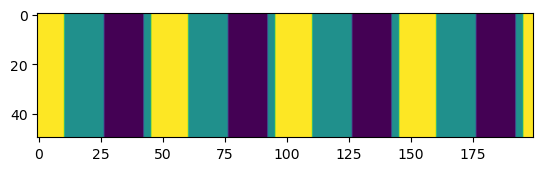

In [63]:
gain = 1 / np.log(15000)
dv = gain*np.log(stack[200,:]) - gain*np.log(stack[199,:])
print(dv.max(), dv.min())
dv[dv < params["neg_th"]] = -1
dv[dv >= params["pos_th"]] = 1
dv[(dv > params["neg_th"]) & (dv < params["pos_th"])] = 0
# Show an example log differential frame
plt.figure()
plt.imshow(dv)

print(stack[199].min())
print(gain*np.log(stack[199,:]).min())
print((gain*np.log(stack[200,:]) - gain*np.log(stack[199,:])).min())

In [64]:
# Now lets feed the video into the forward model and check the result
events, frames = es.forward(stack, reset=True)  # DO NOT directly call _events_from_stack as forward incorporates error catching protocols

# Check if events are correct
print(events)


[]


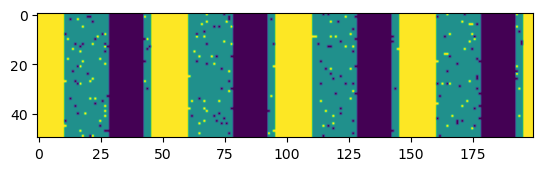

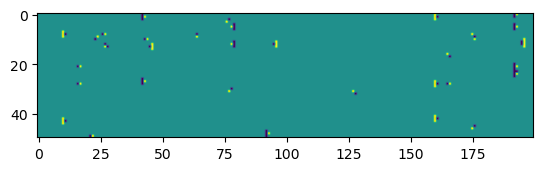

In [65]:
HEIGHT = 50
WIDTH = 200

plt.figure()
plt.imshow(torch.squeeze(frames[200,:]).detach().cpu().numpy())

ba_filter = BAFilter(time_threshold=1, height=HEIGHT, width=WIDTH)
filtered_frames = ba_filter.filter_frames_tensor(frames.unsqueeze(1), inplace=False)

plt.figure()
plt.imshow(torch.squeeze(filtered_frames[200,:]).detach().cpu().numpy())

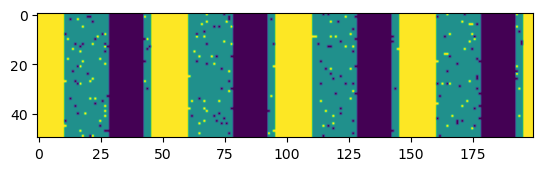

In [66]:
plt.figure()
plt.imshow(torch.squeeze(frames[200,:]).detach().cpu().numpy())

In [67]:
# visualize output frames to see event encoding

# write a video to the notebook to visualize result!
with VideoWriter(fps=30) as vw:
    for i in tqdm(range(vid_size[0])):

        # for visualization
        vw.add((frames[i,:].detach().cpu().numpy()+1)/2)

100%|██████████| 250/250 [00:00<00:00, 1239.80it/s]


In [68]:
# Demo using torch to process events with BAF

# set input of frames correctly. Unfold expects [N, C, X, Y] and current [N, X, Y]
frames = frames[:, None, :]

## Define grad true

polarity = frames # create a sparse matrix to track polarity of all input events
frames = torch.abs(frames)  # insert channel dimension and return magnitude of all events
N, C, X, Y = frames.shape  # determine the nominal shape of the input


# Setup user parameters
tkern = 1  # support in dt of spatiotemporal window: IN REAL SCRIPT ENFORCE TO BE ODD
tau = 0.25 # sparsest spatiotemporal neightborhood allowable: IN REAL SCRIPT ENFORCE BETWEEN 0 to 1
skern = 3  # spatial support of event signal: IN REAL SCRIPT ENFORCE TO BE ODD


torch.Size([250, 1, 50, 200])


tensor(1.)

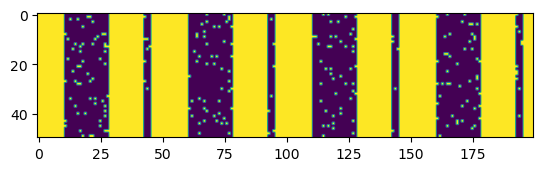

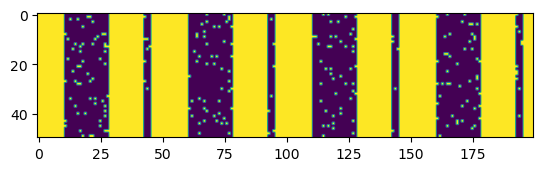

In [69]:
# First step: Determine temporal support of surrounding pixels. This is equivilent to investigating the rolling sum of all events at a pixel location in some temporal range. This is a 1D convolution along the N dimension
t_frames = frames.permute(1, 2, 3, 0)  # permute so time axis is first
t_frames = t_frames.view(-1, N)[:, None, :]  # reshape such that [minibatches, channels, timepoints]

# setup the kernel
kern = torch.ones(tkern)[None, None, :] # in real version, just replace frames

# apply convolution and reshape to nominal shape
t_frames = torch.nn.functional.conv1d(t_frames, kern, stride=1, padding='same')  # perform 1D conv
t_frames = t_frames.squeeze(0).view(C, X, Y, N)  # reshape result
t_frames = t_frames.permute(3, 0, 1, 2)  # This is a spatial map WEIGHTED by their temporal neighbors at each pixel.
print(t_frames.shape)

# sanity check
plt.figure()
plt.imshow(np.squeeze(frames[200, :]))

plt.figure()
plt.imshow(np.squeeze(t_frames[200, :]))

t_frames.max()

In [70]:
# Second step: Determine weighted spatial support in a rolling window. This can be done by looking at the unfolded image along the XY dimension unwrapping by a 3x3 neighborhood
# setup parameters for torch unfold
unfold_params = dict(
    kernel_size = (skern, skern),  # kernel size in x,y
    dilation=1, # no dilation
    padding=1,  # zero padding will reduce errors along edge at the cost of some activity
    stride=1  #no stride
)

unfold = torch.nn.Unfold(**unfold_params)  # create an instance of the unfold class
t_frames = unfold(t_frames)  # since have inverse operation, can overwrite original
print(t_frames.size())  # check output size. Should be [N, (3x3), L] where L is from documentation: https://pytorch.org/docs/stable/generated/torch.nn.Unfold.html

torch.Size([250, 9, 10000])


In [71]:
# Third: analyze within window and filter
# # Here, the filter considers two aspects: support and density of events. If any entries are zero OR the density of events in this neightborhood is low, reject event
# mask1, _ = torch.min(t_frames, 
# dim=1, keepdim=True)  # use min to determine zero values and remove indicies
# t_frames = mask1 * t_frames

# apply BAF filtering, which only preserves events that have A nonzero neighbor spatiotemporally
mid = skern**2//2
filt = torch.ones((skern**2))
filt[mid] = 0
filt = filt[None, :, None]
mask1, _ = torch.max(t_frames*filt, dim=1, keepdim=True)  # remove central value in each window then use max to determine if any nonzeroes exist. Normalize by maximum possible value, tkern
mask1 = mask1 / tkern

print(mask1.size())

mask1 = torch.nn.functional.pad(mask1, pad=(0, 0, (skern**2-1)//2, (skern**2-1)//2))
t_frames = mask1 * t_frames

# mask2 = torch.sum(t_frames, dim=1, keepdim=True) > (tau * skern**2 * tkern)  # this mask looks at total event density in neighborhood
# mask2 = torch.nn.functional.pad(mask2, pad=(0, 0, (skern**2-1)//2, (skern**2-1)//2))  # pad to nominal side such that we only preserve central events

# # apply
# t_frames = mask2 * t_frames

torch.Size([250, 1, 10000])


In [72]:
print(mask1.size())
print(len(torch.nonzero(mask1)))

print(t_frames.max())

torch.Size([250, 9, 10000])
1946292
tensor(1.)


In [73]:
# Step 4: Reshape and Check
fold = torch.nn.Fold(output_size = (X, Y), **unfold_params)
t_frames = fold(t_frames)  # fold adds each replica together so end result is pixel * win_size

print(t_frames.size())
print(t_frames.max())

torch.Size([250, 1, 50, 200])
tensor(1.)


tensor(1.) tensor(0.)


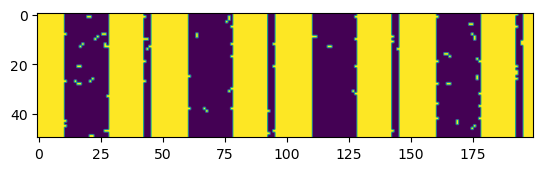

In [74]:
plt.figure()
plt.imshow(np.squeeze(t_frames[200, :]))

print(t_frames.max(), t_frames.min())

torch.Size([250, 1, 50, 200])


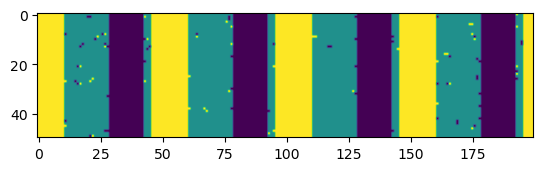

In [75]:
# Last step: reapply polarity
print(polarity.size())
polarity = polarity
t_frames = polarity * torch.ceil(t_frames / tkern)  # reapply binarization and polarization

plt.figure()
plt.imshow(np.squeeze(t_frames[200, :]))

In [76]:
## Check gradient preservation
print(t_frames.max(), t_frames.min())

print(len(torch.nonzero(t_frames)) / (N*X*Y))

tensor(1.) tensor(-1.)
0.5929572
